# Phương pháp 1: Phân tích "Curse of Memory"

## Mục tiêu

Chứng minh rằng khi mạng RNN lưu giữ ký ức dài hạn, **trạng thái ẩn (hidden state)** trở nên cực kỳ nhạy cảm với thay đổi tham số, ngay cả khi giá trị riêng của Jacobian bị ràng buộc gần 1 (không có exploding gradients).

## Mô hình lý thuyết

Xét RNN tuyến tính một chiều đơn giản:
$$h_{k+1} = \lambda h_k + x_k, \quad h_0 = 0$$

Triển khai:
$$h_k = \sum_{i=0}^{k-1} \lambda^{k-1-i} x_i$$

Đạo hàm theo $\lambda$:
$$\frac{\partial h_k}{\partial \lambda} = \sum_{i=0}^{k-2} (k-1-i)\lambda^{k-2-i} x_i$$

Với $x_i \sim \mathcal{N}(0,1)$ độc lập:
$$\text{Var}\left(\frac{\partial h_k}{\partial \lambda}\right) = \sum_{i=0}^{k-2} (k-1-i)^2 \lambda^{2(k-2-i)}$$

Khi $|\lambda| \to 1$, đại lượng này tăng theo bậc $\mathcal{O}(k^3)$ → **bất ổn định**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Bước 1: Mô phỏng RNN tuyến tính và tính độ nhạy với $\lambda$

In [2]:
def simulate_rnn(lam, x):
    """h_{k+1} = lam * h_k + x_k"""
    T = len(x)
    h = np.zeros(T + 1)
    for k in range(T):
        h[k+1] = lam * h[k] + x[k]
    return h

def dh_dlambda(lam, x):
    """Tính dh_k/dlambda bằng auto-recurrence: d_{k+1} = h_k + lam * d_k"""
    T = len(x)
    h = np.zeros(T + 1)
    d = np.zeros(T + 1)
    for k in range(T):
        d[k+1] = h[k] + lam * d[k]
        h[k+1] = lam * h[k] + x[k]
    return d

In [3]:
T = 200
n_samples = 5000
lambdas = [0.5, 0.8, 0.9, 0.95, 0.99]

variance_curves = {}
for lam in lambdas:
    derivs = np.zeros((n_samples, T + 1))
    for s in range(n_samples):
        x = np.random.randn(T)
        derivs[s] = dh_dlambda(lam, x)
    variance_curves[lam] = derivs.var(axis=0)

print('Đã tính phương sai cho', len(lambdas), 'giá trị lambda')

Đã tính phương sai cho 5 giá trị lambda


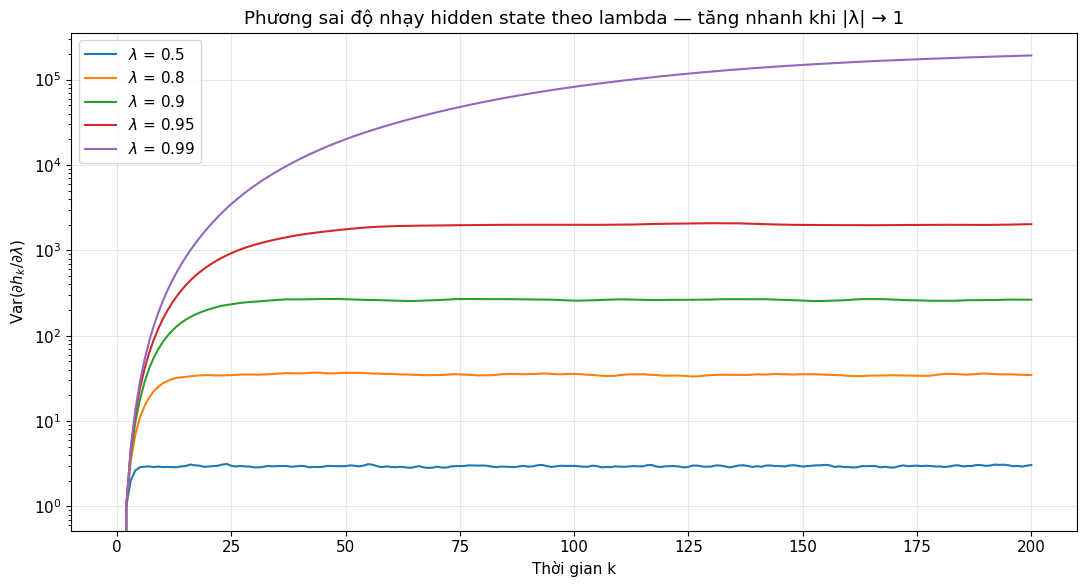

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
k_arr = np.arange(T + 1)
for lam, var in variance_curves.items():
    ax.plot(k_arr, var, label=f'$\\lambda$ = {lam}')
ax.set_yscale('log')
ax.set_xlabel('Thời gian k')
ax.set_ylabel(r'Var($\partial h_k / \partial \lambda$)')
ax.set_title('Phương sai độ nhạy hidden state theo lambda — tăng nhanh khi |λ| → 1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 2: So sánh tốc độ tăng phương sai với công thức lý thuyết

Lý thuyết: $\text{Var}(\partial h_k / \partial \lambda) = \sum_{i=0}^{k-2}(k-1-i)^2 \lambda^{2(k-2-i)}$

Khi $\lambda \to 1$, biến này tăng theo $\mathcal{O}(k^3 / 3)$.

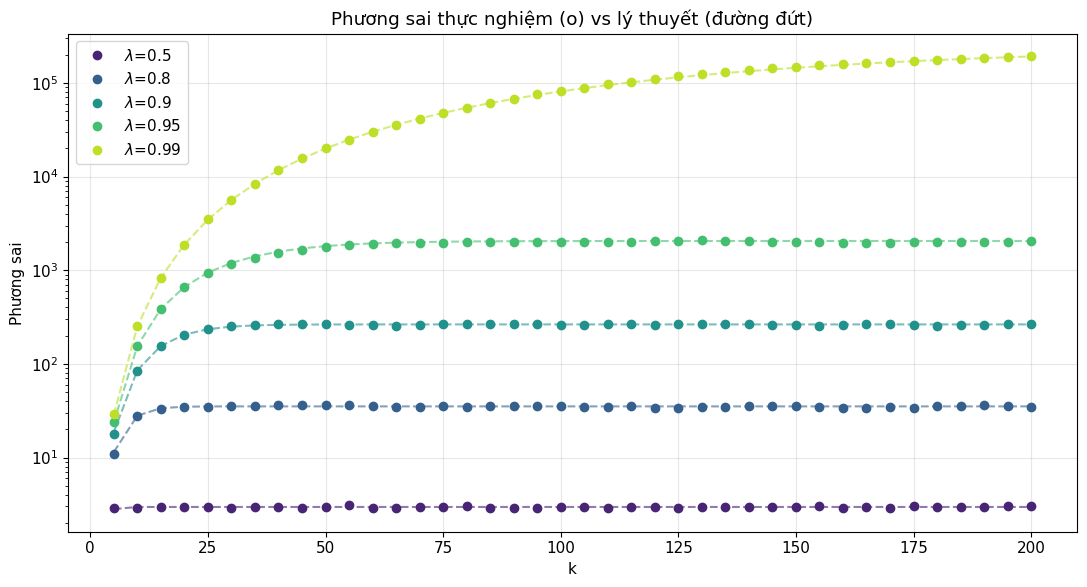

In [5]:
def theoretical_variance(lam, k):
    j = np.arange(k - 1)  # j = k-2-i
    weights = (j + 1) ** 2
    return np.sum(weights * lam ** (2 * j))

k_range = np.arange(5, T + 1, 5)
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lambdas)))
for lam, c in zip(lambdas, colors):
    theo = np.array([theoretical_variance(lam, k) for k in k_range])
    emp = variance_curves[lam][k_range]
    ax.plot(k_range, theo, '--', color=c, alpha=0.6)
    ax.plot(k_range, emp, 'o', color=c, label=f'$\\lambda$={lam}')
ax.set_yscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Phương sai')
ax.set_title('Phương sai thực nghiệm (o) vs lý thuyết (đường đứt)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 3: Quan sát curse of memory theo |λ|

Cố định k=100, vẽ phương sai theo $|\lambda|$ tiến đến 1.

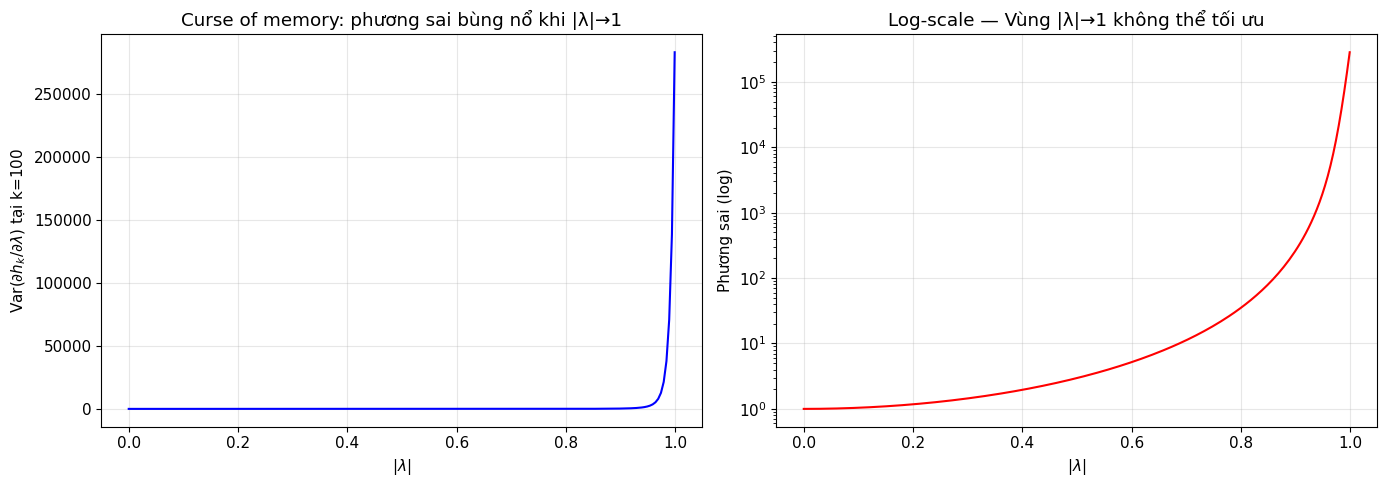

In [6]:
k_fixed = 100
lam_arr = np.linspace(0.0, 0.999, 200)
var_at_k = np.array([theoretical_variance(l, k_fixed) for l in lam_arr])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lam_arr, var_at_k, 'b-')
axes[0].set_xlabel(r'$|\lambda|$')
axes[0].set_ylabel(r'Var($\partial h_k / \partial \lambda$) tại k=100')
axes[0].set_title('Curse of memory: phương sai bùng nổ khi |λ|→1')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lam_arr, var_at_k, 'r-')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$|\lambda|$')
axes[1].set_ylabel('Phương sai (log)')
axes[1].set_title('Log-scale — Vùng |λ|→1 không thể tối ưu')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 4: Chứng minh rằng |λ|<1 KHÔNG đủ để đảm bảo ổn định khi học

Chứng tỏ rằng dù không có exploding gradients (vì |λ|<1), độ nhạy hidden state với tham số vẫn lớn không thể tối ưu được. Đây là điểm mấu chốt của bài báo về **curse of memory**.

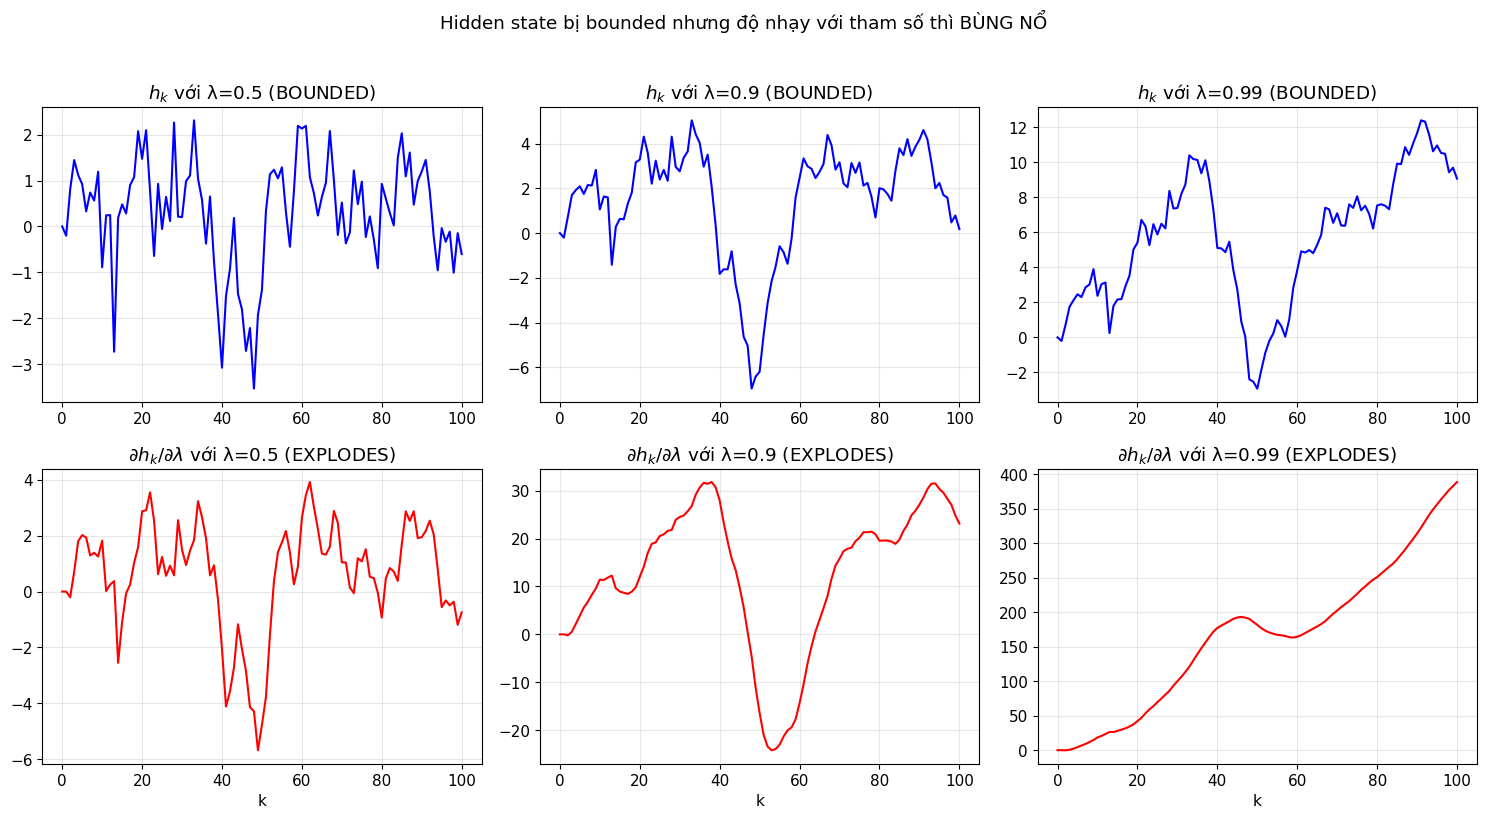


Giá trị lớn nhất của |h_k| và |∂h_k/∂λ|:
lambda    max|h_k|       max|∂h/∂λ|     
0.5       3.5359         5.6765         
0.9       6.9542         31.7997        
0.99      12.4027        388.9284       


In [7]:
T_test = 100
lams = [0.5, 0.9, 0.99]
x_test = np.random.randn(T_test)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, lam in enumerate(lams):
    h = simulate_rnn(lam, x_test)
    d = dh_dlambda(lam, x_test)
    axes[0, col].plot(h, 'b-')
    axes[0, col].set_title(f'$h_k$ với λ={lam} (BOUNDED)')
    axes[0, col].grid(True, alpha=0.3)
    axes[1, col].plot(d, 'r-')
    axes[1, col].set_title(f'$\\partial h_k/\\partial \\lambda$ với λ={lam} (EXPLODES)')
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].set_xlabel('k')
plt.suptitle('Hidden state bị bounded nhưng độ nhạy với tham số thì BÙNG NỔ', y=1.02)
plt.tight_layout()
plt.show()

print('\nGiá trị lớn nhất của |h_k| và |∂h_k/∂λ|:')
print(f"{'lambda':<10}{'max|h_k|':<15}{'max|∂h/∂λ|':<15}")
for lam in lams:
    h = simulate_rnn(lam, x_test)
    d = dh_dlambda(lam, x_test)
    print(f'{lam:<10}{np.max(np.abs(h)):<15.4f}{np.max(np.abs(d)):<15.4f}')

## Kết luận phương pháp 1

- **Hidden state $h_k$ bị bounded** khi $|\lambda|<1$ (không có exploding/vanishing nghĩa cổ điển).
- Nhưng **độ nhạy $\partial h_k/\partial \lambda$ vẫn bùng nổ** theo bậc $\mathcal{O}(k^3)$ khi $\lambda \to 1$.
- Đây chính là biểu hiện đầu tiên của **curse of memory**: ràng buộc spectral radius KHÔNG đủ để RNN học ổn định khi cần ký ức dài.
- Trong các phương pháp tiếp theo, sẽ phân tích chi tiết hơn về tín hiệu truyền, ma trận không chéo, loss landscape, và Hessian.